In [1]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


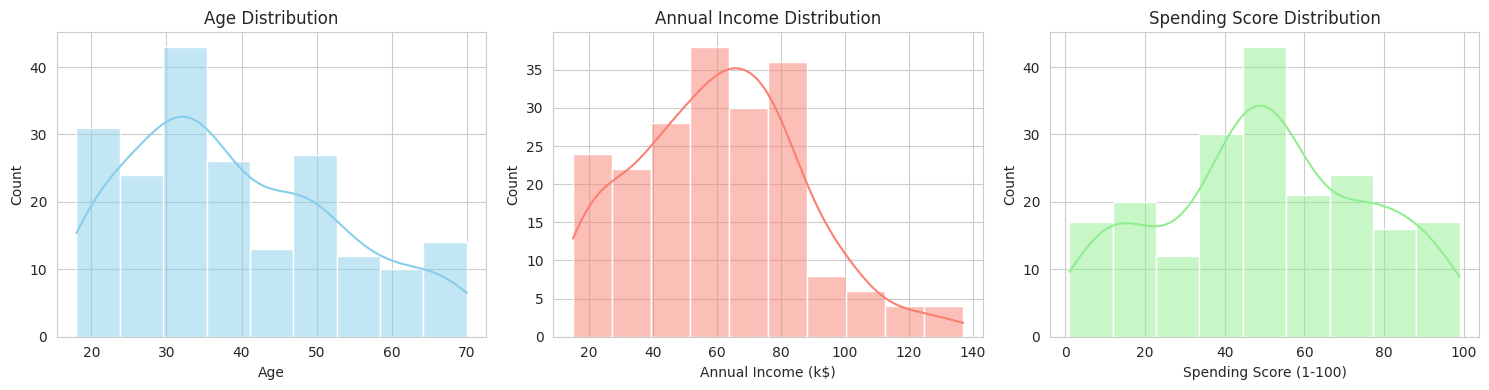

In [7]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(df["Age"], kde=True, color="skyblue")
plt.title("Age Distribution")

plt.subplot(1,3,2)
sns.histplot(df["Annual Income (k$)"], kde=True, color="salmon")
plt.title("Annual Income Distribution")

plt.subplot(1,3,3)
sns.histplot(df["Spending Score (1-100)"], kde=True, color="lightgreen")
plt.title("Spending Score Distribution")

plt.tight_layout()
plt.show()

In [8]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


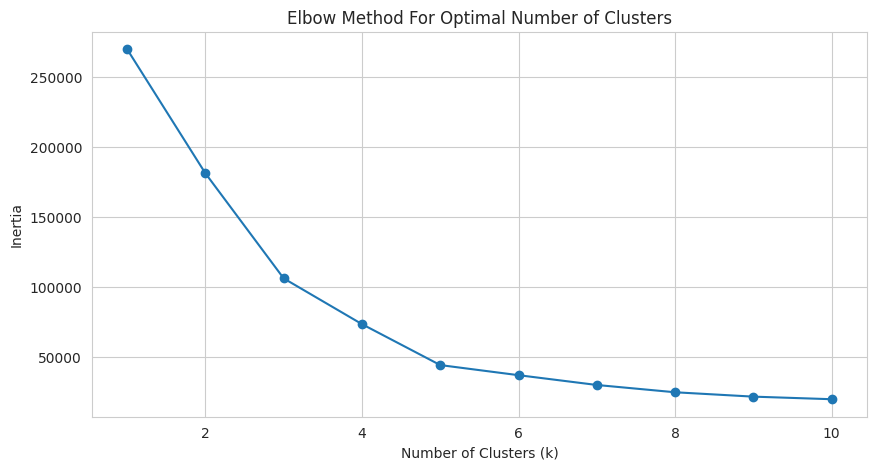

In [9]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method For Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=5, init="k-means++", random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


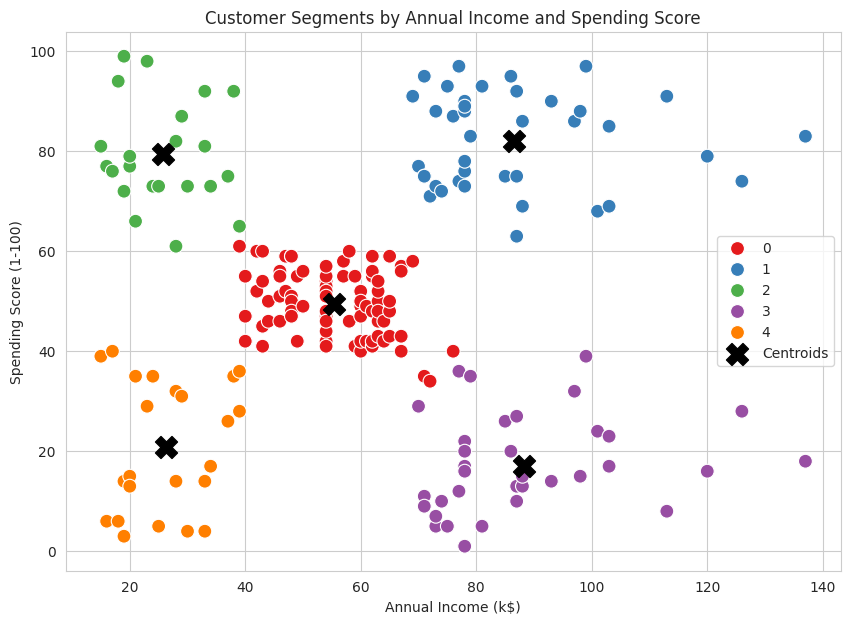

In [11]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=100
)

centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], c="black", s=250, marker="X", label="Centroids")

plt.title("Customer Segments by Annual Income and Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [12]:
cluster_summary = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


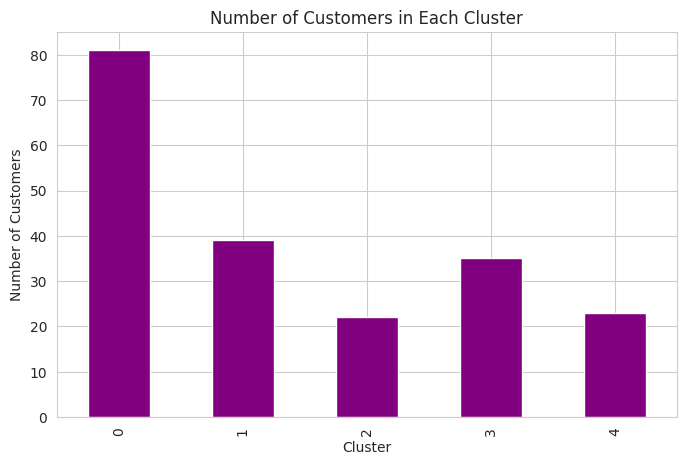

In [13]:
plt.figure(figsize=(8,5))
df["Cluster"].value_counts().sort_index().plot(kind="bar", color="purple")
plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

## Insights and Recommendations

The K-means clustering algorithm grouped the 200 mall customers into 5 distinct segments based on Annual Income and Spending Score:

1. Cluster 0 - Average Customers (81 people, ~41% of customers): Around 43 years old, with mid-range income (~$55k) and mid-range spending (score ~50). This is the largest segment and represents typical, balanced shoppers. General, broad marketing campaigns work best here.

2. Cluster 1 - High Value Customers (39 people): Young (~33 years), high income (~$87k), and high spending score (~82). These are the most profitable customers. They should be prioritized with loyalty programs, premium products, and personalized offers to maximize retention.

3. Cluster 2 - Young Big Spenders (22 people): Young (~25 years), low income (~$26k), but a high spending score (~79). Likely students or early-career shoppers who spend a large share of their income at the mall. Trendy, affordable products and student discounts could appeal to this group.

4. Cluster 3 - Untapped Potential (35 people): Around 41 years old, high income (~$88k), but a low spending score (~17). These customers can clearly afford to spend more but currently aren't engaging with the mall. Targeted, personalized marketing campaigns could help convert this group into higher spenders.

5. Cluster 4 - Low Engagement Customers (23 people): Older (~45 years), low income (~$26k), and low spending score (~21). This is the least active segment and should be the lowest priority for active marketing spend.

Overall, the mall's marketing budget would be best spent retaining Cluster 1 (your most valuable customers) while running targeted campaigns to activate Cluster 3, since they have the income to spend more but currently aren't.